# Customer Lifetime Value (CLV) Prediction and Segmentation

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay


### Loading Dataset

In [121]:
df=pd.read_csv('Dataset.csv',encoding='latin3')

In [122]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### Data Cleaning

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [124]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode  ... CustomerID         Country
0         536365    85123A  ...    17850.0  United Kingdom
1         536365     71053  ...    17850.0  United Kingdom
2         536365    84406B  ...    17850.0  United Kingdom
3         536365    84029G  ...    17850.0  United Kingdom
4         536365    84029E  ...    17850.0  United Kingdom
...          ...       ...  ...        ...             ...
541904    581587     22613  ...    12680.0          France
541905    581587     22899  ...    12680.0          France
541906    581587     23254  ...    12680.0          France
541907    581587     23255  ...    12680.0          France
541908    581587     22138  ...    12680.0          France

[541909 rows x 8 columns]>

In [125]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [126]:
df.duplicated().sum()

np.int64(5268)

In [127]:
df.shape

(541909, 8)

In [128]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [129]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [130]:
df=df.dropna(subset=['CustomerID'])

In [131]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [132]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

C:\Users\athra\AppData\Local\Temp\ipykernel_15928\3737639551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


In [133]:
df['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 406829, dtype: datetime64[ns]

In [ ]:
count=len(df)
df=df[df['Quantity']>0] ##Remove Return Product
df=df[df['UnitPrice']>0] ## Remove Invalid Price
removed_rows=count-len(df)
print(f"Removed Invalid Rows are:{removed_rows}") 

Removed Rows are:8945


In [200]:
print(f"Remaining Rows are:- {len(df)}")

Remaining Rows are:- 397884


In [143]:
df['Total_Amount']=df['Quantity']*df['UnitPrice']

In [145]:
df.shape

(397884, 9)

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     397884 non-null  object        
 1   StockCode     397884 non-null  object        
 2   Description   397884 non-null  object        
 3   Quantity      397884 non-null  int64         
 4   InvoiceDate   397884 non-null  datetime64[ns]
 5   UnitPrice     397884 non-null  float64       
 6   CustomerID    397884 non-null  float64       
 7   Country       397884 non-null  object        
 8   Total_Amount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


### Distribution of Purchased Quantity

In [134]:
''' 
The Distribution of Purchased quantity was analysisted to understand 
Customer buying bhevaiour 
''';

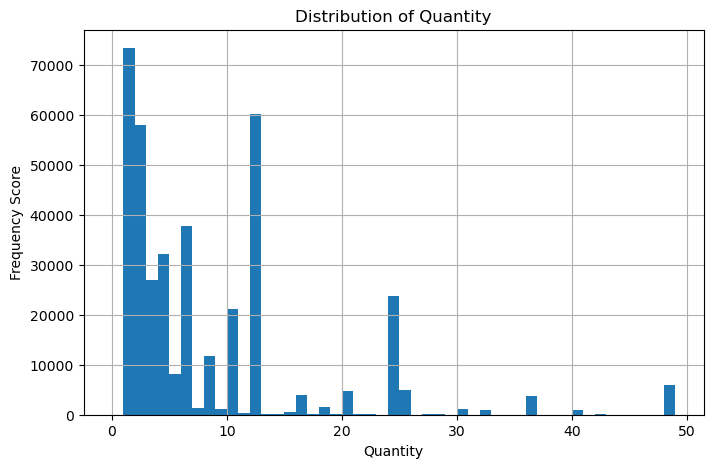

In [147]:

plt.figure(figsize=(8,5))
plt.hist(df['Quantity'],bins=range(0,50))
plt.title("Distribution of Quantity") 
plt.xlabel('Quantity')
plt.ylabel('Frequency Score')
plt.grid()
plt.show()

In [136]:
'''
Observation:- 
Most transactions contains small purchased quantity,
while few transactions involves large purchased quantity
''';

### Distribution of Unit Price

In [137]:
''' 
Distribution of Selling Price of product were analysisted 
''';

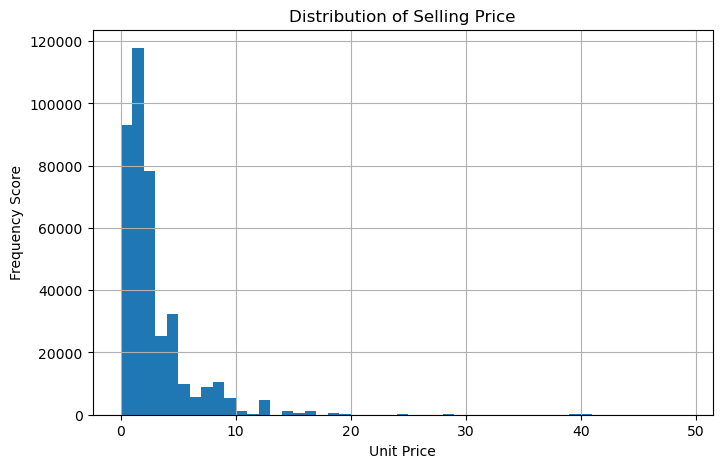

In [148]:
plt.figure(figsize=(8,5))
plt.hist(df['UnitPrice'],bins=range(0,50))
plt.title("Distribution of Selling Price") 
plt.xlabel('Unit Price')
plt.ylabel('Frequency Score')
plt.grid()
plt.show()

In [177]:
revenue_customer=df.groupby('CustomerID')['Total_Amount'].sum().reset_index()

In [180]:
revenue_customer.rename(columns={"Total_Amount":"Revenue"}, inplace=True)

In [181]:
revenue_customer

,CustomerID,Revenue
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2094.88


### Distribution of Revenue Per Customer

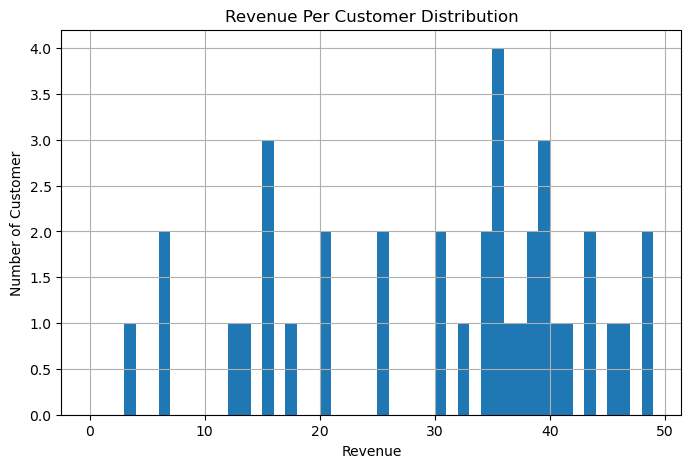

In [199]:
plt.figure(figsize=(8,5))
plt.hist(revenue_customer['Revenue'],bins=range(0,50))
plt.title('Revenue Per Customer Distribution')
plt.xlabel('Revenue')
plt.ylabel('Number of Customer')
plt.grid()
plt.show()